# BetaVAE Latent Space Explorer & ONNX Exporter

This notebook contains helper cells to:
1. Define the v4.1 BetaVAE architecture (including the `SpatialAttention` module matching the saved weights).
2. Load `checkpointv4.1.pth`.
3. Extract and export `EncoderOnly` and `DecoderOnly` wrappers to ONNX formats (`encoderv4.1.onnx` and `decoderv4.1.onnx`), automatically verifying them and placing copies in `frontend/public/`.
4. Run the encoder over a subset of training/validation images to calculate and visualize the statistical bounds (min, max, mean, std) for each of the 16 latent dimensions.
5. Find a common direction vector representing facial attributes (e.g. smiling, gender, glasses) from custom positive and negative image folders.

## 1. Imports

In [1]:
import os
import glob
import shutil
import numpy as np
import matplotlib.pyplot as plt
from PIL import Image
from tqdm import tqdm

import torch
import torch.nn as nn
import torch.nn.utils.spectral_norm as spectral_norm
from torch.utils.data import DataLoader
from torchvision import datasets, transforms
import onnx

## 2. Model Architecture (v4.1)

These classes define the ResDownBlock, ResUpBlock, SpatialAttention, and the full BetaVAE model exactly as it was configured in the `animev4.1.ipynb` training setup.

In [2]:
class ResDownBlock(nn.Module):
    def __init__(self, in_channels, out_channels):
        super(ResDownBlock, self).__init__()

        # Main path
        self.main = nn.Sequential(
            nn.Conv2d(in_channels, out_channels, kernel_size=4, stride=2, padding=1),
            nn.GroupNorm(8, out_channels),
            nn.LeakyReLU(0.2, inplace=True),
            nn.Conv2d(out_channels, out_channels, kernel_size=3, stride=1, padding=1),
            nn.GroupNorm(8, out_channels)
        )

        # Skip path
        self.shortcut = nn.Sequential(
            nn.Conv2d(in_channels, out_channels, kernel_size=1, stride=2),
            nn.GroupNorm(8, out_channels)
        )

        self.act = nn.LeakyReLU(0.2, inplace=True)

    def forward(self, x):
        return self.act(self.main(x) + self.shortcut(x))


class ResUpBlock(nn.Module):
    def __init__(self, in_channels, out_channels):
        super(ResUpBlock, self).__init__()

        # Main path
        self.main = nn.Sequential(
            nn.Upsample(scale_factor=2, mode='bilinear', align_corners=False),
            nn.Conv2d(in_channels, out_channels, kernel_size=3, padding=1),
            nn.GroupNorm(8, out_channels),
            nn.LeakyReLU(0.2, inplace=True),
            nn.Conv2d(out_channels, out_channels, kernel_size=3, padding=1),
            nn.GroupNorm(8, out_channels)
        )

        # Skip Path
        self.shortcut = nn.Sequential(
            nn.Upsample(scale_factor=2, mode='bilinear', align_corners=False),
            nn.Conv2d(in_channels, out_channels, kernel_size=1),
            nn.GroupNorm(8, out_channels)
        )

        self.act = nn.LeakyReLU(0.2, inplace=True)

    def forward(self, x):
        return self.act(self.main(x) + self.shortcut(x))


class SpatialAttention(nn.Module):
    def __init__(self, in_channels):
        super().__init__()
        self.query = nn.Conv2d(in_channels, in_channels // 8, kernel_size=1)
        self.key   = nn.Conv2d(in_channels, in_channels // 8, kernel_size=1)
        self.value = nn.Conv2d(in_channels, in_channels, kernel_size=1)
        self.gamma = nn.Parameter(torch.zeros(1))
        self.softmax = nn.Softmax(dim=-1)

    def forward(self, x):
        B, C, H, W = x.shape
        N = H * W

        q = self.query(x).view(B, -1, N).permute(0, 2, 1)  # (B, N, C//8)
        k = self.key(x).view(B, -1, N)                      # (B, C//8, N)
        v = self.value(x).view(B, -1, N)                    # (B, C, N)

        attn = self.softmax(torch.bmm(q, k))
        out = torch.bmm(v, attn.permute(0, 2, 1)).view(B, C, H, W)
        return self.gamma * out + x


class BetaVAE(nn.Module):
    def __init__(self, latent_dim=16):
        super(BetaVAE, self).__init__()

        # Encoder: 3x64x64 -> Latent Space
        self.encoder = nn.Sequential(
            ResDownBlock(3, 32),
            ResDownBlock(32, 64),
            ResDownBlock(64, 128),
            ResDownBlock(128, 256),
            SpatialAttention(256),
            nn.Flatten()
        )

        self.fc_mu = nn.Linear(4096, latent_dim)
        self.fc_logvar = nn.Linear(4096, latent_dim)

        # Decoder: Latent Space -> 3x64x64
        self.decoder_input = nn.Linear(latent_dim, 4096)
        self.decoder = nn.Sequential(
            nn.Unflatten(1, (256, 4, 4)),
            SpatialAttention(256),
            ResUpBlock(256, 128),
            ResUpBlock(128, 64),
            ResUpBlock(64, 32),
            nn.Upsample(scale_factor=2, mode='bilinear', align_corners=False),
            nn.Conv2d(32, 32, kernel_size=3, padding=1),
            nn.LeakyReLU(negative_slope=0.2, inplace=True),
            nn.Conv2d(32, 3, kernel_size=3, padding=1),
            nn.Sigmoid()
        )

    def reparameterize(self, mu, logvar):
        std = torch.exp(0.5 * logvar)
        eps = torch.randn_like(std)
        return mu + eps * std

    def forward(self, x):
        h = self.encoder(x)
        mu = self.fc_mu(h)
        logvar = self.fc_logvar(h)
        logvar = torch.clamp(logvar, min=-20.0, max=20.0)
        z = self.reparameterize(mu, logvar)
        return self.decoder(self.decoder_input(z)), mu, logvar

## 3. Load Checkpoint

Ensure `checkpointv4.1.pth` is in the same directory as this notebook (or adjust the path).

In [3]:
latent_dim = 16
device = torch.device("cuda" if torch.cuda.is_available() else "mps" if torch.backends.mps.is_available() else "cpu")
print(f"Using device: {device}")

model = BetaVAE(latent_dim=latent_dim).to(device)
checkpoint_path = './checkpointv4.1.pth'

if os.path.exists(checkpoint_path):
    checkpoint = torch.load(checkpoint_path, map_location=device)
    model.load_state_dict(checkpoint['model_state_dict'])
    print(f"Successfully loaded weights from {checkpoint_path} (epoch {checkpoint.get('epoch', 'N/A')})")
else:
    print(f"Error: Checkpoint file not found at '{checkpoint_path}'!")

Using device: cpu
Successfully loaded weights from ./checkpointv4.1.pth (epoch 20)


## 4. Extract and Export Encoder & Decoder to ONNX

We define wrapper classes to isolate `EncoderOnly` (image to latent vector `mu`) and `DecoderOnly` (latent vector `z` to reconstructed image), export them, check validity, and copy to the frontend public assets directory.

In [4]:
class EncoderOnly(torch.nn.Module):
    def __init__(self, full_model):
        super().__init__()
        self.encoder = full_model.encoder
        self.fc_mu = full_model.fc_mu

    def forward(self, x):
        h = self.encoder(x)
        return self.fc_mu(h)

class DecoderOnly(torch.nn.Module):
    def __init__(self, full_model):
        super().__init__()
        self.decoder_input = full_model.decoder_input
        self.decoder = full_model.decoder

    def forward(self, z):
        x = self.decoder_input(z)
        return self.decoder(x)

# 1. Export Encoder
encoder_model = EncoderOnly(model).to(device).eval()
dummy_img = torch.randn(1, 3, 64, 64).to(device)

torch.onnx.export(
    encoder_model,
    dummy_img,
    "encoderv4.1.onnx",
    export_params=True,
    opset_version=12,
    do_constant_folding=True,
    input_names=['input_image'],
    output_names=['latent_z']
)
print("Exported raw encoderv4.1.onnx")

# 2. Export Decoder
decoder_model = DecoderOnly(model).to(device).eval()
latent_input = torch.randn(1, latent_dim).to(device)

torch.onnx.export(
    decoder_model,
    latent_input,
    "decoderv4.1.onnx",
    export_params=True,
    opset_version=12,
    do_constant_folding=True,
    input_names=['latent_z'],
    output_names=['reconstruction']
)
print("Exported raw decoderv4.1.onnx")

# 3. Verify models using onnx package
for filename in ["encoderv4.1.onnx", "decoderv4.1.onnx"]:
    onnx_m = onnx.load(filename)
    onnx.checker.check_model(onnx_m)
    onnx.save(onnx_m, filename)
    print(f"Verified and validated {filename} successfully.")

# 4. Copy to frontend public directory
dest_dir = "./frontend/public"
if os.path.exists(dest_dir):
    shutil.copy("encoderv4.1.onnx", os.path.join(dest_dir, "encoderv4.1.onnx"))
    shutil.copy("decoderv4.1.onnx", os.path.join(dest_dir, "decoderv4.1.onnx"))
    print(f"Copied models to {dest_dir}/")
else:
    print(f"Frontend folder not found at '{dest_dir}'. ONNX files left in current directory.")

W0628 12:10:58.050000 15013 torch/onnx/_internal/exporter/_compat.py:125] Setting ONNX exporter to use operator set version 18 because the requested opset_version 12 is a lower version than we have implementations for. Automatic version conversion will be performed, which may not be successful at converting to the requested version. If version conversion is unsuccessful, the opset version of the exported model will be kept at 18. Please consider setting opset_version >=18 to leverage latest ONNX features
W0628 12:10:58.602000 15013 torch/onnx/_internal/exporter/_schemas.py:455] Missing annotation for parameter 'input' from (input, boxes, output_size: 'Sequence[int]', spatial_scale: 'float' = 1.0, sampling_ratio: 'int' = -1, aligned: 'bool' = False). Treating as an Input.
W0628 12:10:58.604000 15013 torch/onnx/_internal/exporter/_schemas.py:455] Missing annotation for parameter 'boxes' from (input, boxes, output_size: 'Sequence[int]', spatial_scale: 'float' = 1.0, sampling_ratio: 'int' 

[torch.onnx] Obtain model graph for `EncoderOnly([...]` with `torch.export.export(..., strict=False)`...
[torch.onnx] Obtain model graph for `EncoderOnly([...]` with `torch.export.export(..., strict=False)`... ✅
[torch.onnx] Run decomposition...


/usr/lib/python3.12/copyreg.py:99: FutureWarning: `isinstance(treespec, LeafSpec)` is deprecated, use `isinstance(treespec, TreeSpec) and treespec.is_leaf()` instead.
  return cls.__new__(cls, *args)
The model version conversion is not supported by the onnxscript version converter and fallback is enabled. The model will be converted using the onnx C API (target version: 12).
Failed to convert the model to the target version 12 using the ONNX C API. The model was not modified
Traceback (most recent call last):
  File "/home/aayush/code/ML_DL/.venv/lib/python3.12/site-packages/onnxscript/version_converter/__init__.py", line 120, in call
    converted_proto = _c_api_utils.call_onnx_api(
                      ^^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "/home/aayush/code/ML_DL/.venv/lib/python3.12/site-packages/onnxscript/version_converter/_c_api_utils.py", line 65, in call_onnx_api
    result = func(proto)
             ^^^^^^^^^^^
  File "/home/aayush/code/ML_DL/.venv/lib/python3.12/site-packages/

[torch.onnx] Run decomposition... ✅
[torch.onnx] Translate the graph into ONNX...
[torch.onnx] Translate the graph into ONNX... ✅
Exported raw encoderv4.1.onnx


W0628 12:11:00.307000 15013 torch/onnx/_internal/exporter/_schemas.py:455] Missing annotation for parameter 'input' from (input, boxes, output_size: 'Sequence[int]', spatial_scale: 'float' = 1.0, sampling_ratio: 'int' = -1, aligned: 'bool' = False). Treating as an Input.
W0628 12:11:00.308000 15013 torch/onnx/_internal/exporter/_schemas.py:455] Missing annotation for parameter 'boxes' from (input, boxes, output_size: 'Sequence[int]', spatial_scale: 'float' = 1.0, sampling_ratio: 'int' = -1, aligned: 'bool' = False). Treating as an Input.
W0628 12:11:00.310000 15013 torch/onnx/_internal/exporter/_schemas.py:455] Missing annotation for parameter 'input' from (input, boxes, output_size: 'Sequence[int]', spatial_scale: 'float' = 1.0). Treating as an Input.
W0628 12:11:00.312000 15013 torch/onnx/_internal/exporter/_schemas.py:455] Missing annotation for parameter 'boxes' from (input, boxes, output_size: 'Sequence[int]', spatial_scale: 'float' = 1.0). Treating as an Input.


[torch.onnx] Obtain model graph for `DecoderOnly([...]` with `torch.export.export(..., strict=False)`...
[torch.onnx] Obtain model graph for `DecoderOnly([...]` with `torch.export.export(..., strict=False)`... ✅
[torch.onnx] Run decomposition...


/usr/lib/python3.12/copyreg.py:99: FutureWarning: `isinstance(treespec, LeafSpec)` is deprecated, use `isinstance(treespec, TreeSpec) and treespec.is_leaf()` instead.
  return cls.__new__(cls, *args)
The model version conversion is not supported by the onnxscript version converter and fallback is enabled. The model will be converted using the onnx C API (target version: 12).
Failed to convert the model to the target version 12 using the ONNX C API. The model was not modified
Traceback (most recent call last):
  File "/home/aayush/code/ML_DL/.venv/lib/python3.12/site-packages/onnxscript/version_converter/__init__.py", line 120, in call
    converted_proto = _c_api_utils.call_onnx_api(
                      ^^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "/home/aayush/code/ML_DL/.venv/lib/python3.12/site-packages/onnxscript/version_converter/_c_api_utils.py", line 65, in call_onnx_api
    result = func(proto)
             ^^^^^^^^^^^
  File "/home/aayush/code/ML_DL/.venv/lib/python3.12/site-packages/

[torch.onnx] Run decomposition... ✅
[torch.onnx] Translate the graph into ONNX...
[torch.onnx] Translate the graph into ONNX... ✅
Exported raw decoderv4.1.onnx
Verified and validated encoderv4.1.onnx successfully.
Verified and validated decoderv4.1.onnx successfully.
Copied models to ./frontend/public/


## 5. Running the Model and Visualizing Latent Space Bounds

We load a representative subset of the training/validation set, encode them, and calculate the actual bounds (minimum, maximum, mean, std) for each dimension to guide our UI slider bounds.

Found a total of 63565 images in dataset directory.
Encoding first 2000 images to calculate latent statistics...


100%|██████████| 2000/2000 [00:10<00:00, 198.57it/s]


Encoded 2000 images successfully.

--- LATENT SPACE DIMENSIONAL STATISTICS ---
Dimension 01 | Min: -2.4945 | Max: 2.8504 | Mean: 0.3232 | Std: 0.8232
Dimension 02 | Min: -1.7839 | Max: 1.4573 | Mean: -0.2189 | Std: 0.4332
Dimension 03 | Min: -1.6910 | Max: 2.8099 | Mean: -0.0267 | Std: 0.6905
Dimension 04 | Min: -1.5130 | Max: 1.9859 | Mean: 0.1707 | Std: 0.5178
Dimension 05 | Min: -1.6250 | Max: 1.5681 | Mean: -0.2103 | Std: 0.4627
Dimension 06 | Min: -2.6478 | Max: 1.9492 | Mean: -0.1658 | Std: 0.7278
Dimension 07 | Min: -1.6259 | Max: 1.5818 | Mean: -0.0260 | Std: 0.4731
Dimension 08 | Min: -1.5158 | Max: 1.6981 | Mean: 0.1521 | Std: 0.4810
Dimension 09 | Min: -2.7336 | Max: 2.3482 | Mean: 0.0204 | Std: 0.8909
Dimension 10 | Min: -1.9402 | Max: 1.6562 | Mean: 0.1865 | Std: 0.5244
Dimension 11 | Min: -1.5991 | Max: 1.4953 | Mean: 0.0645 | Std: 0.4384
Dimension 12 | Min: -2.6032 | Max: 2.5887 | Mean: -0.0918 | Std: 0.8799
Dimension 13 | Min: -1.3003 | Max: 1.2991 | Mean: 0.0663 | Std:

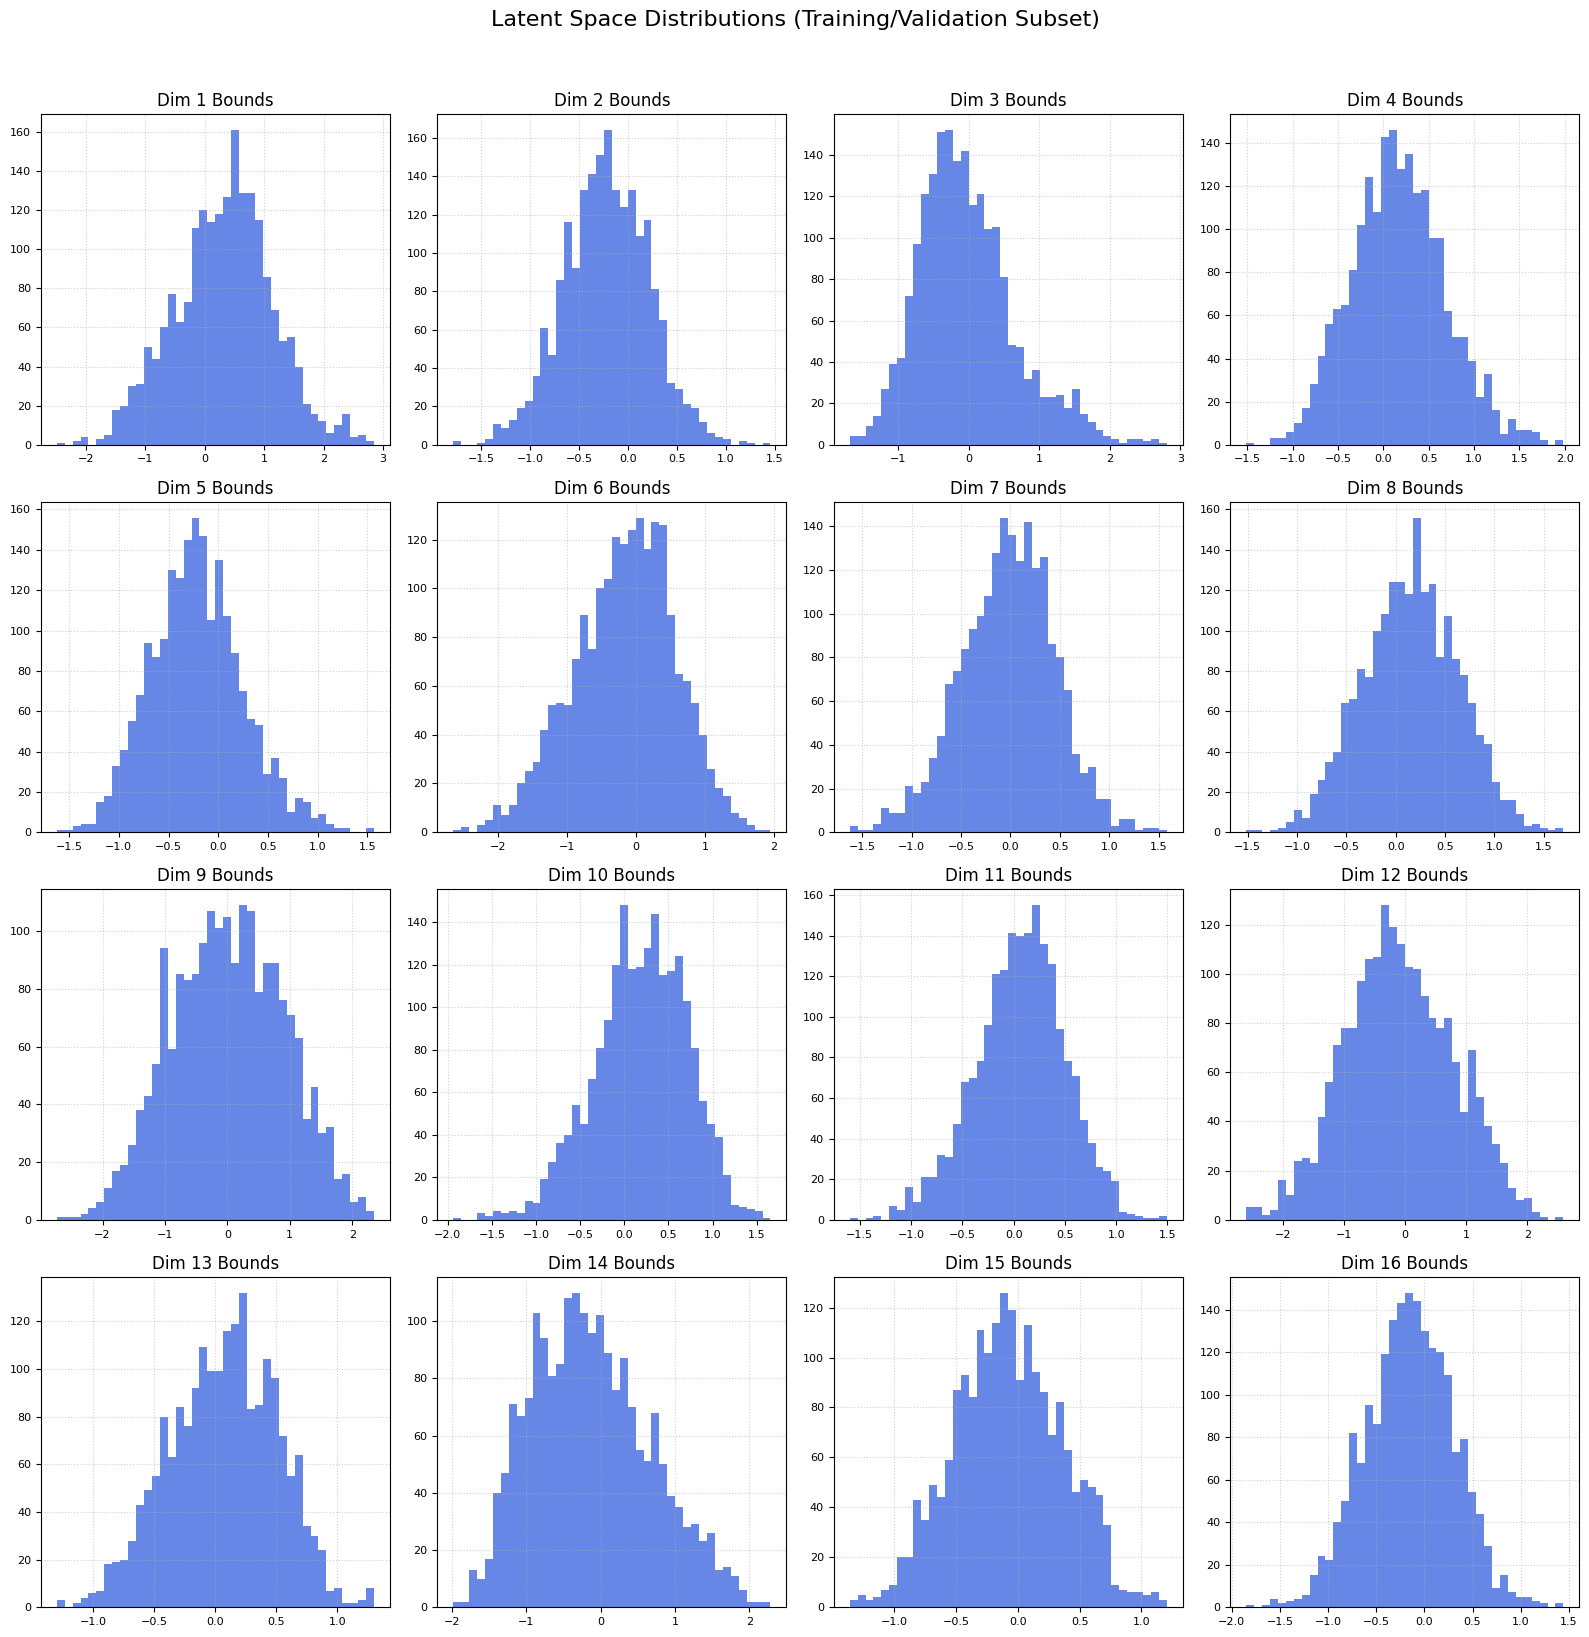

In [5]:
# Preprocessing transform
eval_transform = transforms.Compose([
    transforms.Resize((64, 64)),
    transforms.ToTensor(),
])

# Search directories for dataset images
image_paths = glob.glob('./anime_faces/**/*.jpg', recursive=True) + glob.glob('./anime_faces/**/*.png', recursive=True)
print(f"Found a total of {len(image_paths)} images in dataset directory.")

if len(image_paths) == 0:
    print("Warning: No images found under './anime_faces/'. Bounds check cannot proceed. Please place training images there.")
else:
    # Limit encoding count to prevent running out of memory/time
    limit = min(2000, len(image_paths))
    print(f"Encoding first {limit} images to calculate latent statistics...")
    
    all_z = []
    encoder_model.eval()
    with torch.no_grad():
        for idx in tqdm(range(limit)):
            p = image_paths[idx]
            try:
                img = Image.open(p).convert('RGB')
                tensor = eval_transform(img).unsqueeze(0).to(device)
                z = encoder_model(tensor)
                all_z.append(z.cpu().numpy()[0])
            except Exception as e:
                # Skip corrupted or invalid images
                pass

    all_z = np.array(all_z) # (N, 16)
    print(f"Encoded {len(all_z)} images successfully.")
    
    # Calculate stats
    print("\n--- LATENT SPACE DIMENSIONAL STATISTICS ---")
    for dim in range(16):
        vals = all_z[:, dim]
        print(f"Dimension {dim+1:02d} | Min: {vals.min():.4f} | Max: {vals.max():.4f} | Mean: {vals.mean():.4f} | Std: {vals.std():.4f}")

    # Plot distributions
    fig, axes = plt.subplots(4, 4, figsize=(16, 16))
    for dim in range(16):
        ax = axes[dim // 4, dim % 4]
        ax.hist(all_z[:, dim], bins=40, color='royalblue', edgecolor='none', alpha=0.8)
        ax.set_title(f"Dim {dim+1} Bounds")
        ax.grid(True, linestyle=':', alpha=0.6)
        ax.tick_params(labelsize=8)
    plt.suptitle("Latent Space Distributions (Training/Validation Subset)", fontsize=16, y=1.02)
    plt.tight_layout()
    plt.show()

## 6. Find Latent Direction Vector for Custom Attributes

Provide a path to custom folders containing images WITH a certain attribute (positive folder) and optionally images WITHOUT it (negative control folder) to find the semantic direction vector.

In [ ]:
# Set custom directories containing images
positive_attribute_dir = "/home/aayush/code/ML_DL/faces/custom_path/smiling"
negative_attribute_dir = "/home/aayush/code/ML_DL/faces/custom_path/neutral"

def encode_directory_images(directory, max_images=100):
    if not os.path.exists(directory):
        print(f"Directory does not exist: '{directory}'")
        return None

    image_exts = ('*.jpg', '*.jpeg', '*.png', '*.webp')
    files = []
    for ext in image_exts:
        files.extend(glob.glob(os.path.join(directory, ext)))
        files.extend(glob.glob(os.path.join(directory, ext.upper())))
    
    if not files:
        print(f"No image files found in '{directory}'")
        return None
    
    print(f"Found {len(files)} images in '{directory}'. Encoding up to {max_images}...")
    z_vectors = []
    encoder_model.eval()
    with torch.no_grad():
        for f in files[:max_images]:
            try:
                img = Image.open(f).convert('RGB')
                tensor = eval_transform(img).unsqueeze(0).to(device)
                z = encoder_model(tensor)
                z_vectors.append(z.cpu().numpy()[0])
            except Exception as e:
                print(f"Failed to process {f}: {e}")
    return np.array(z_vectors) if z_vectors else None

# 1. Encode Positive Set
z_pos = encode_directory_images(positive_attribute_dir)

# 2. Encode Negative Set (Optional)
z_neg = encode_directory_images(negative_attribute_dir)

if z_pos is not None:
    mean_pos = np.mean(z_pos, axis=0)
    
    if z_neg is not None:
        mean_neg = np.mean(z_neg, axis=0)
        direction = mean_pos - mean_neg
        description = "Difference between Positive and Negative mean"
    else:
        # If no control folder, subtract the overall database mean from the positive set mean
        overall_mean = all_z.mean(axis=0) if 'all_z' in locals() else np.zeros(16)
        direction = mean_pos - overall_mean
        description = "Difference between Positive mean and overall dataset mean"
    
    # Normalize direction to unit length
    norm_val = np.linalg.norm(direction)
    if norm_val > 0:
        direction = direction / norm_val
        print(f"\nSuccess! Computed semantic direction vector ({description}).")
        print("\n--- NORMALIZED DIRECTION VECTOR (16 DIM) ---")
        for dim, val in enumerate(direction):
            print(f"Dim {dim+1:02d}: {val:+.6f}")
            
        # Save direction vector
        output_path = "./attribute_direction_vector.npy"
        np.save(output_path, direction)
        print(f"\nSaved direction vector to: '{output_path}'")
    else:
        print("Error: Direction vector length is 0.")
else:
    print("\n[Usage Note]: Provide a valid path to a positive folder to compute the direction vector.")